In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt
import pickle

In [6]:
df=pd.read_csv('D:\Anuj\Placement Training\MLops-Training\Day-8\Task-18\mtsamples.csv')
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [7]:
df=df[['transcription', 'medical_specialty']]
df=df.dropna()

In [8]:
df['medical_specialty'].value_counts()

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Cosmetic / Plastic Surgery         27
Dentistry                       

In [9]:
selected = [
    ' Cardiovascular / Pulmonary',
    ' Orthopedic',
    ' Gastroenterology',
    ' Neurology',
    ' Urology',
    ' Obstetrics / Gynecology',
    ' ENT - Otolaryngology',
    ' Neurosurgery',
    ' Hematology - Oncology',
    ' Ophthalmology',
    ' Nephrology'
]

In [10]:
df=df[df['medical_specialty'].isin(selected)]
balanced_df=pd.DataFrame()
for specialty in selected:
    temp=df[
        df['medical_specialty'] == specialty
    ].sample(80, random_state=42)
    balanced_df = pd.concat([balanced_df, temp])

In [11]:
top15=df['medical_specialty'].value_counts().head(15).index
df=df[df['medical_specialty'].isin(top15)]

In [12]:
le=LabelEncoder()
balanced_df['specialty_encoded']=le.fit_transform(balanced_df['medical_specialty'])

In [13]:
X=balanced_df['transcription']
y=balanced_df['specialty_encoded']

In [14]:
cv=TfidfVectorizer(stop_words='english',max_features=10000)
X=cv.fit_transform(X)

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)
predictions=model.predict(X_test)

In [18]:
cm=confusion_matrix(y_test, predictions)

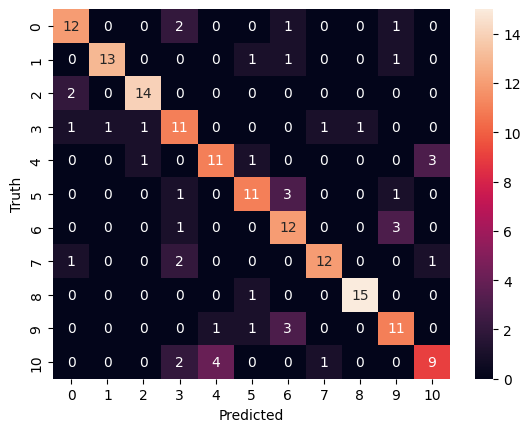

In [19]:
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [20]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        16
           1       0.93      0.81      0.87        16
           2       0.88      0.88      0.88        16
           3       0.58      0.69      0.63        16
           4       0.69      0.69      0.69        16
           5       0.73      0.69      0.71        16
           6       0.60      0.75      0.67        16
           7       0.86      0.75      0.80        16
           8       0.94      0.94      0.94        16
           9       0.65      0.69      0.67        16
          10       0.69      0.56      0.62        16

    accuracy                           0.74       176
   macro avg       0.75      0.74      0.75       176
weighted avg       0.75      0.74      0.75       176



In [21]:
with open('model.pkl','wb') as file:
    pickle.dump(model,file)

In [22]:
with open('encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

In [23]:
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(cv, file)